# Detecting Machine-Generated Text
## A Comparative Classification Approach — SemEval-2024 Task 8 (Subtask A)

| | |
|---|---|
| **Name** | Yiğit Sert |
| **Number** | Y255050003 |
| **Course** | SWE 530 – Advanced Natural Language Processing |
| **Task** | Binary Classification — Human-written (0) vs. Machine-generated (1) |

---

### Background & Motivation

The rapid proliferation of Large Language Models (LLMs) — GPT-4, Claude, Gemini, and their variants — has made it increasingly difficult to distinguish human-authored content from machine-generated text. This challenge is consequential across several domains:

- **Academic integrity:** AI-generated submissions passed off as original student work
- **Cybersecurity:** Automated phishing, disinformation, and social engineering at scale
- **Misinformation:** Synthetic news articles indistinguishable from genuine journalism

This project frames the problem as a **supervised binary text classification** task and benchmarks it against [SemEval-2024 Task 8](https://aclanthology.org/2024.semeval-1.279/), a standardized shared task attracting 126 participating teams worldwide.

---

### Experimental Pipeline Overview

A two-path experimental design is followed:

| Path | Method | Feature Representation |
|------|--------|------------------------|
| **A — Traditional ML** | Logistic Regression, Naïve Bayes | TF-IDF (unigram + bigram) |
| **B — Deep Learning** | Fine-tuned RoBERTa | Contextual embeddings (Transformer) |

**Data partitioning:**

| Split | Source | Role |
|-------|--------|------|
| Training set (80%) | `subtaskA_train_monolingual.jsonl` | Model fitting |
| Test set (20%) | `subtaskA_train_monolingual.jsonl` (held-out) | Final unseen evaluation |
| Validation set | `subtaskA_dev_monolingual.jsonl` | Hyperparameter tuning & epoch selection |

**Primary evaluation metric:** Macro F1-Score (as specified by SemEval-2024 Task 8 organizers), ensuring balanced performance across both classes regardless of label distribution.

---

### Key References

1. Wang et al. (2024). *SemEval-2024 Task 8: Multigenerator, Multidomain, and Multilingual Black-Box Machine-Generated Text Detection.* NAACL SemEval-2024.
2. Sharma & Mansuri (2024). *Team Innovative at SemEval-2024 Task 8.* SemEval-2024. *(Primary methodology reference — RoBERTa hybrid approach)*
3. Liu et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692.


---
## Section 0 — Environment Setup & Dependency Installation

All required libraries are installed in this section.

| Library | Purpose |
|---------|---------|
| `transformers` | Pre-trained Transformer models (RoBERTa) and training utilities |
| `datasets` | Efficient HuggingFace Dataset objects for the Trainer API |
| `evaluate` | Metric computation helpers used internally by `Trainer` |
| `scikit-learn` | TF-IDF vectorizer, Logistic Regression, Naïve Bayes, metrics |
| `accelerate` | Backend acceleration for HuggingFace `Trainer` (GPU/CPU dispatch) |
| `pandas`, `matplotlib`, `seaborn` | Data manipulation and visualization |


In [21]:
!pip install -q transformers datasets evaluate scikit-learn pandas matplotlib seaborn
!pip install -q accelerate -U

### Downloading the SemEval-2024 Task 8 Dataset

Subtask A – Monolingual (English) from the official HuggingFace mirror is used.

- **Training source:** `subtaskA_train_monolingual.jsonl` — split 80/20 into train and test sets
- **Validation source:** `subtaskA_dev_monolingual.jsonl` — used as-is for validation during fine-tuning

Each record contains a `text` field and a `label` field (`0` = Human, `1` = Machine). The dataset spans multiple domains (Wikipedia, news, student essays, abstracts) and multiple LLM generators (ChatGPT, GPT-3, Cohere, Davinci, Bloomz, Dolly).


In [22]:
BASE_URL = "https://huggingface.co/datasets/anyangsong/SemEval2024-Task8-SubtaskA/resolve/main/monolingual"

!wget -q $BASE_URL/subtaskA_train_monolingual.jsonl -O train_source.jsonl
!wget -q $BASE_URL/subtaskA_dev_monolingual.jsonl   -O val.jsonl

print("Download complete: train_source.jsonl | val.jsonl")

Download complete: train_source.jsonl | val.jsonl


---
## Section 1 — Imports & Global Configuration

All imports are consolidated here for clarity. A global `FAST_TEST_MODE` flag is defined:

- **`FAST_TEST_MODE = True`** — The dataset is subsampled (5,000 train / 1,000 val / 1,000 test) and training runs for 2 epochs. Intended for rapid debugging on CPU or a small GPU.
- **`FAST_TEST_MODE = False`** — The full dataset is used with 3 training epochs for publication-quality results.

> ⚠️ **Hardware Note:** RoBERTa fine-tuning (Path B) is computationally intensive. A CUDA-capable GPU is strongly recommended. The available device is detected automatically.


In [23]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch

# ── Path A: Traditional Machine Learning ─────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Path B: Deep Learning (Transformers) ─────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

# ── GLOBAL CONFIGURATION ─────────────────────────────────────────────────────
FAST_TEST_MODE = False         # Set to True for quick debugging
RANDOM_SEED    = 42
TEST_SIZE      = 0.20          # 20% of train_source → held-out test set

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active device : {device.type.upper()}")
if device.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU detected — RoBERTa fine-tuning will be slow on CPU.")

print(f"\nFAST_TEST_MODE : {FAST_TEST_MODE}")
print(f"Test split     : {int(TEST_SIZE*100)}% of training source")
print(f"Random seed    : {RANDOM_SEED}")

Active device : CUDA
  GPU  : Tesla T4
  VRAM : 15.6 GB

FAST_TEST_MODE : False
Test split     : 20% of training source
Random seed    : 42


---
## Section 2 — Data Loading, Splitting & Exploratory Data Analysis

### 2.1 Load the Dataset

Both source files are loaded into Pandas DataFrames.


In [24]:
df_source = pd.read_json("train_source.jsonl", lines=True)
df_val    = pd.read_json("val.jsonl",          lines=True)

print(f"Source file : {df_source.shape[0]:>7,} rows")
print(f"Val file    : {df_val.shape[0]:>7,} rows")
print(f"\nLabel counts in source file:")
print(df_source['label'].value_counts().rename({0: 'Human (0)', 1: 'Machine (1)'}))

Source file : 119,757 rows
Val file    :   5,000 rows

Label counts in source file:
label
Human (0)      63351
Machine (1)    56406
Name: count, dtype: int64


### 2.2 Train / Test Split

The training source file is partitioned into an **80% training set** and a **20% test set** using stratified sampling.

**Justification:**
- An 80/20 ratio is a well-established default that provides sufficient training signal while reserving enough samples for a statistically meaningful test evaluation.
- Stratification on the `label` column ensures that the class balance is preserved across both splits.
- The `dev` file (already provided by SemEval-2024 organisers) is used directly as the **validation set** during RoBERTa fine-tuning.

This three-way partitioning prevents any form of data leakage between model selection (validation), hyperparameter tuning (training), and final reporting (test).


In [25]:
# ── Stratified 80/20 split ────────────────────────────────────────────────────
df_train_full, df_test_full = train_test_split(
    df_source,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=df_source['label']
)

df_train_full = df_train_full.reset_index(drop=True)
df_test_full  = df_test_full.reset_index(drop=True)

# ── Optional subsampling for FAST_TEST_MODE ───────────────────────────────────
if FAST_TEST_MODE:
    print("FAST TEST MODE — subsampling dataset...")
    df_train = df_train_full.sample(n=5000, random_state=RANDOM_SEED).reset_index(drop=True)
    df_test  = df_test_full.sample(n=1000,  random_state=RANDOM_SEED).reset_index(drop=True)
    df_val   = df_val.sample(n=1000,        random_state=RANDOM_SEED).reset_index(drop=True)
else:
    df_train = df_train_full.copy()
    df_test  = df_test_full.copy()

print(f"\n{'Split':<12} {'Rows':>8}  {'Human':>8}  {'Machine':>8}")
print("─" * 44)
for name, df in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    h = (df['label'] == 0).sum()
    m = (df['label'] == 1).sum()
    print(f"{name:<12} {len(df):>8,}  {h:>8,}  {m:>8,}")
print("─" * 44)
print(f"\nTotal available for training : {len(df_train):,}")
print(f"Validation (SemEval dev)     : {len(df_val):,}")
print(f"Test (held-out, unseen)      : {len(df_test):,}")


Split            Rows     Human   Machine
────────────────────────────────────────────
Train          95,805    50,680    45,125
Validation      5,000     2,500     2,500
Test           23,952    12,671    11,281
────────────────────────────────────────────

Total available for training : 95,805
Validation (SemEval dev)     : 5,000
Test (held-out, unseen)      : 23,952


### 2.3 Stylometric Analysis — Text Length Distributions

Stylometry studies measurable linguistic features of writing style. Text length (word count and character count) serves as a basic discriminative signal. Prior research has shown that LLMs tend to produce more uniformly structured texts within a consistent length range, whereas human writing exhibits higher variance.

Word count and character count distributions are visualised separately for human-authored and machine-generated samples.


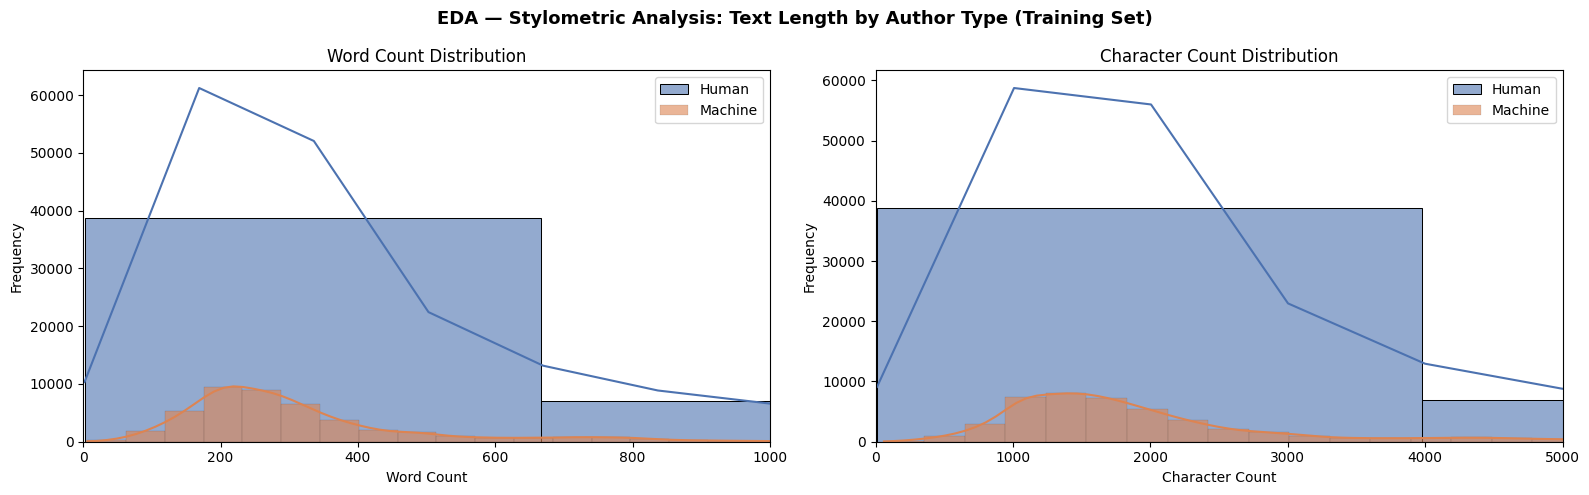


Word count summary by label (Training Set):
      word_count                                                  char_count                                                        
           count   mean    std  min    25%    50%    75%      max      count    mean     std   min     25%     50%     75%       max
label                                                                                                                               
0        50680.0  588.6  865.1  2.0  206.0  297.0  631.0  33223.0    50680.0  3548.7  5321.8  10.0  1283.0  1804.0  3726.0  198470.0
1        45125.0  317.6  192.1  6.0  201.0  267.0  363.0   2830.0    45125.0  1930.5  1108.8  60.0  1230.0  1648.0  2227.0   14807.0


In [26]:
for df, title in [(df_train, "Training Set"), (df_test, "Test Set")]:
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
    df['char_count'] = df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("EDA — Stylometric Analysis: Text Length by Author Type (Training Set)",
             fontsize=13, fontweight='bold')

palette = {0: '#4C72B0', 1: '#DD8452'}
labels_map = {0: 'Human', 1: 'Machine'}

for label_val, color in palette.items():
    subset = df_train[df_train['label'] == label_val]
    sns.histplot(subset['word_count'], bins=50, kde=True, ax=axes[0],
                 color=color, label=labels_map[label_val], alpha=0.6)
    sns.histplot(subset['char_count'], bins=50, kde=True, ax=axes[1],
                 color=color, label=labels_map[label_val], alpha=0.6)

axes[0].set_title('Word Count Distribution'); axes[0].set_xlabel('Word Count')
axes[0].set_xlim(0, 1000); axes[0].legend(); axes[0].set_ylabel('Frequency')
axes[1].set_title('Character Count Distribution'); axes[1].set_xlabel('Character Count')
axes[1].set_xlim(0, 5000); axes[1].legend(); axes[1].set_ylabel('Frequency')

plt.tight_layout(); plt.show()

print("\nWord count summary by label (Training Set):")
print(df_train.groupby('label')[['word_count', 'char_count']].describe().round(1).to_string())

### 2.4 Vocabulary Analysis — Top-20 Word Frequencies

Beyond text length, the vocabulary chosen by human vs. AI writers can differ meaningfully. AI-generated texts often favour formal, precise, or structurally repetitive language patterns, while humans tend to use more colloquial, varied, or domain-specific vocabulary.

The 20 most frequent content words (after stop word removal) are extracted from each class to surface these lexical differences.


/tmp/ipykernel_827/3715966200.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w[1] for w in top_human], y=[w[0] for w in top_human],
/tmp/ipykernel_827/3715966200.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w[1] for w in top_ai], y=[w[0] for w in top_ai],


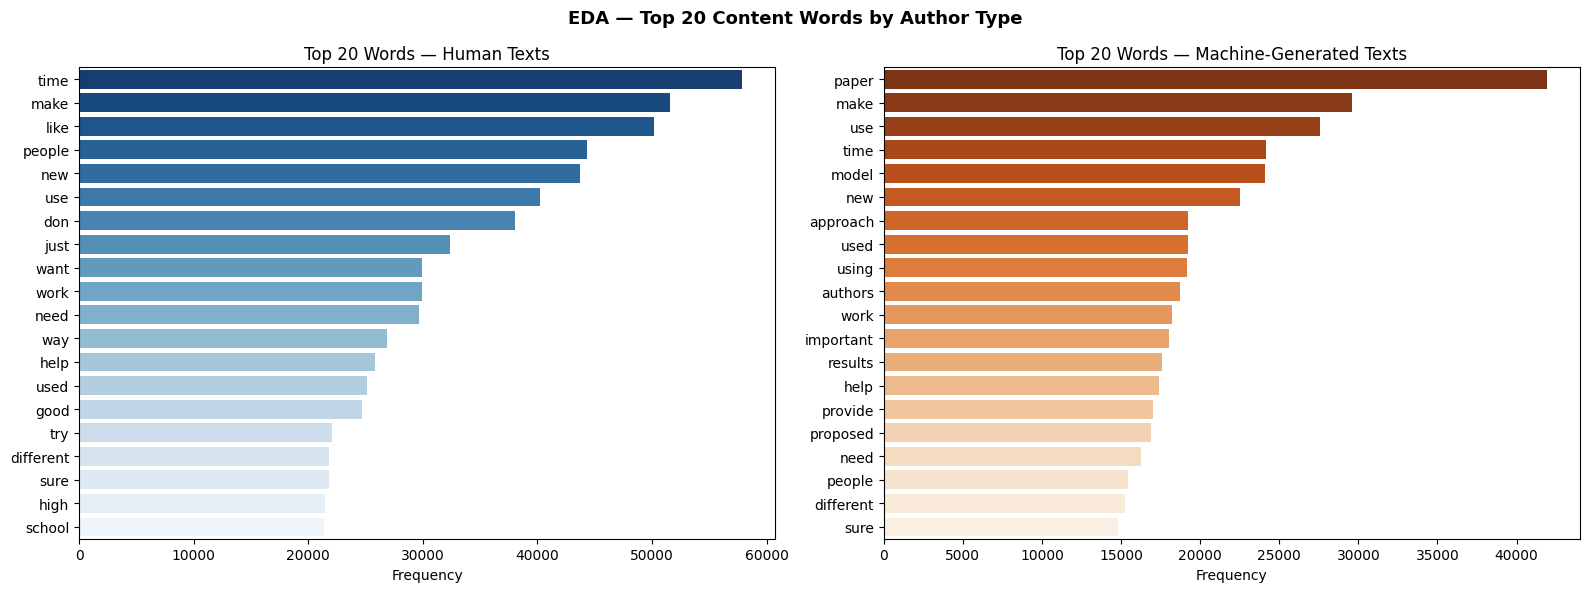

In [27]:
def get_top_n_words(corpus: pd.Series, n: int = 20) -> list:
    """Return the top-n most frequent words after stop word removal."""
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    freq = bag.sum(axis=0)
    word_freq = [(w, freq[0, i]) for w, i in vec.vocabulary_.items()]
    return sorted(word_freq, key=lambda x: x[1], reverse=True)[:n]

human_text = df_train[df_train['label'] == 0]['text']
ai_text    = df_train[df_train['label'] == 1]['text']

top_human = get_top_n_words(human_text)
top_ai    = get_top_n_words(ai_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("EDA — Top 20 Content Words by Author Type", fontsize=13, fontweight='bold')

sns.barplot(x=[w[1] for w in top_human], y=[w[0] for w in top_human],
            ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 20 Words — Human Texts'); axes[0].set_xlabel('Frequency')

sns.barplot(x=[w[1] for w in top_ai], y=[w[0] for w in top_ai],
            ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 20 Words — Machine-Generated Texts'); axes[1].set_xlabel('Frequency')

plt.tight_layout(); plt.show()

---
## Section 3 — Text Preprocessing for Traditional Models

Traditional ML models operate on fixed-size numeric feature vectors. Before TF-IDF extraction, lightweight text normalisation is applied:

1. **Lowercasing** — vocabulary size is reduced by collapsing case variants (`The` → `the`)
2. **Punctuation & special character removal** — only alphanumeric tokens and spaces are retained, reducing noise in the bag-of-words representation

> **Note:** This preprocessing step is intentionally **not** applied to the Transformer path (Section 5). RoBERTa's tokenizer uses BPE subword tokenization and benefits from retaining punctuation and capitalisation, as these carry syntactic signals captured during pre-training.


In [28]:
def clean_text(text: str) -> str:
    """Lowercase and remove all non-alphanumeric characters (TF-IDF path only)."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

for df in [df_train, df_val, df_test]:
    df['clean_text'] = df['text'].apply(clean_text)

print("Text normalisation complete.")
print("\nOriginal sample (first 200 chars):")
print(df_train['text'].iloc[0][:200])
print("\nCleaned sample (first 200 chars):")
print(df_train['clean_text'].iloc[0][:200])

Text normalisation complete.

Original sample (first 200 chars):
When it comes to the 'why' we want to drink milk or water when we consume something 'rich' like chocolate, there are a few reasons to consider. To begin, both milk and water serve important roles in t

Cleaned sample (first 200 chars):
when it comes to the why we want to drink milk or water when we consume something rich like chocolate there are a few reasons to consider to begin both milk and water serve important roles in the proc


---
## Section 4 — Path A: Traditional Baselines (TF-IDF + LR / NB)

### 4.1 TF-IDF Vectorization

**TF-IDF (Term Frequency – Inverse Document Frequency)** converts raw text into a weighted numerical matrix where:
- **TF** rewards terms that appear frequently within a document
- **IDF** penalises terms that appear frequently across all documents (common, uninformative words)

The standard unigram approach is extended with **bigrams** (`ngram_range=(1, 2)`), allowing the model to capture two-word phrases such as *"research suggests"* or *"it is"* — constructions that may differ systematically between AI and human text.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `max_features` | 10,000 | Controls vocabulary size; limits memory and overfitting |
| `stop_words` | `'english'` | Removes high-frequency, low-information function words |
| `ngram_range` | `(1, 2)` | Captures both individual tokens and two-word collocations |

The vectoriser is **fit on the training set only** and then applied to validation and test sets to prevent data leakage.


In [29]:
vectorizer = TfidfVectorizer(
    max_features=10_000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Fit on training data only — transform all three splits
X_train_tfidf = vectorizer.fit_transform(df_train['clean_text'])
X_val_tfidf   = vectorizer.transform(df_val['clean_text'])
X_test_tfidf  = vectorizer.transform(df_test['clean_text'])

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f"TF-IDF matrix shapes")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")
print(f"  Vocabulary size : {len(vectorizer.vocabulary_):,} features")

TF-IDF matrix shapes
  Train : (95805, 10000)
  Val   : (5000, 10000)
  Test  : (23952, 10000)
  Vocabulary size : 10,000 features


### 4.2 Classifier Training & Evaluation

Two interpretable classifiers are trained on the TF-IDF feature space:

**Logistic Regression**
A discriminative linear model that learns a decision boundary in the TF-IDF feature space. Effective for high-dimensional, sparse text data. `max_iter=1000` ensures convergence for this vocabulary size.

**Multinomial Naïve Bayes**
A generative probabilistic model that assumes feature independence. Despite this simplification, NB performs well on text classification with TF-IDF counts.

Both models are evaluated on the **held-out test set** using the four metrics defined by SemEval-2024 Task 8 organisers.


In [30]:
# ── Train classifiers ─────────────────────────────────────────────────────────
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
nb_clf = MultinomialNB()

lr_clf.fit(X_train_tfidf, y_train)
nb_clf.fit(X_train_tfidf, y_train)

# ── Generate predictions on test set ──────────────────────────────────────────
lr_preds = lr_clf.predict(X_test_tfidf)
nb_preds = nb_clf.predict(X_test_tfidf)

print("Logistic Regression and Naïve Bayes trained.")
print(f"Predictions generated on test set ({len(y_test):,} samples).")

Logistic Regression and Naïve Bayes trained.
Predictions generated on test set (23,952 samples).


─────────────────────────────────────────────
  Model     : Logistic Regression
  Accuracy  : 0.8811
  Precision : 0.8849  (class 1 — Machine)
  Recall    : 0.8593  (class 1 — Machine)
  Macro F1  : 0.8805  ← primary metric
─────────────────────────────────────────────



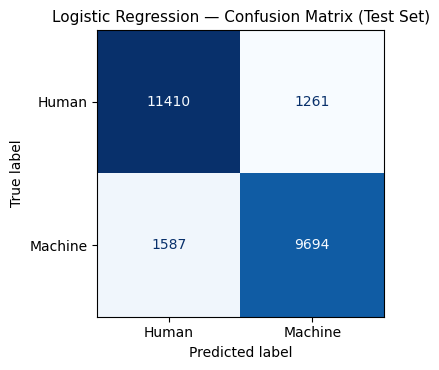

─────────────────────────────────────────────
  Model     : Naïve Bayes
  Accuracy  : 0.7045
  Precision : 0.7084  (class 1 — Machine)
  Recall    : 0.6334  (class 1 — Machine)
  Macro F1  : 0.7011  ← primary metric
─────────────────────────────────────────────



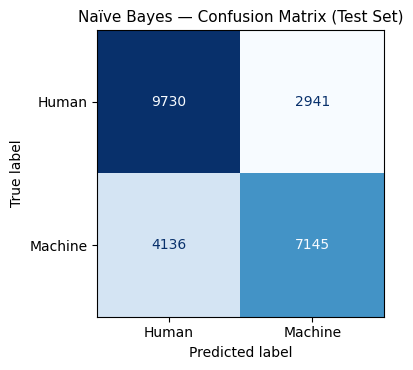

In [31]:
# ── Shared metrics store ──────────────────────────────────────────────────────
model_metrics = {}

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> None:
    """
    Evaluation metrics are computed and displayed for a binary classifier.
    Accuracy and Macro F1 are stored in the global model_metrics dictionary.
    A confusion matrix is plotted for the test set results.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro')

    model_metrics[model_name] = {'Accuracy': acc, 'Macro F1': f1}

    print(f"{'─'*45}")
    print(f"  Model     : {model_name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (class 1 — Machine)")
    print(f"  Recall    : {rec:.4f}  (class 1 — Machine)")
    print(f"  Macro F1  : {f1:.4f}  ← primary metric")
    print(f"{'─'*45}\n")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Human', 'Machine'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{model_name} — Confusion Matrix (Test Set)", fontsize=11)
    plt.tight_layout()
    plt.show()

evaluate_model(y_test, lr_preds, "Logistic Regression")
evaluate_model(y_test, nb_preds, "Naïve Bayes")

---
## Section 5 — Path B: Deep Learning — Fine-tuning RoBERTa

### 5.1 Why RoBERTa?

[**RoBERTa**](https://arxiv.org/abs/1907.11692) (*Robustly Optimized BERT Pretraining Approach*, Liu et al. 2019) is a BERT variant trained with significantly more data, longer sequences, and without the Next Sentence Prediction objective. These modifications produced substantial improvements over BERT on downstream NLP benchmarks.

For machine-generated text detection, Transformer-based models hold a decisive advantage over TF-IDF baselines:

- **Contextual embeddings** — the same word receives different representations depending on surrounding context, capturing subtle semantic differences
- **Pre-training on large corpora** — patterns of human writing are internalised during pre-training
- **Subword tokenisation** — morphological variations and rare/novel vocabulary are handled robustly

Sharma & Mansuri (SemEval-2024, primary reference) achieved **89% validation accuracy** using a RoBERTa hybrid approach, confirming the model's strong baseline performance for this task.

**Architecture Overview:**

```
Input Text
    ↓
BPE Tokenisation (vocab ~50k)
    ↓
Token Embeddings + Positional Embeddings + Segment Embeddings
    ↓
12 × Transformer Encoder Blocks
│   ├─ Multi-Head Self-Attention (12 heads, d_model=768)
│   ├─ Add & LayerNorm
│   ├─ Feed-Forward (hidden=3072, GELU activation)
│   └─ Add & LayerNorm
    ↓
[CLS] token representation (768-dim)
    ↓
Dropout (p=0.1)
    ↓
Linear Classification Head (768 → 2)
    ↓
Softmax → P(Human), P(Machine)
```


### 5.2 Dataset Preparation for the Trainer API

The HuggingFace `Trainer` API requires data as `Dataset` objects with tokenised inputs. DataFrames are converted to HuggingFace `Dataset` objects, and the RoBERTa tokenizer is applied with truncation and padding to a fixed length of **256 tokens**.

> **Why 256 tokens?** The full RoBERTa context window is 512 tokens. 256 strikes a practical balance: it covers the vast majority of texts in the dataset while halving memory consumption and training time — essential for constrained compute environments. Texts exceeding this limit lose the tail of their content, which is an acceptable trade-off given that the first 256 tokens typically carry the most discriminative stylistic signal.


In [32]:
# ── Convert to HuggingFace Dataset objects ────────────────────────────────────
hf_train = Dataset.from_pandas(df_train[['text', 'label']].reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val[['text', 'label']].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test[['text', 'label']].reset_index(drop=True))

# ── Load tokeniser ─────────────────────────────────────────────────────────────
MODEL_NAME = "roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(examples: dict) -> dict:
    """A batch of texts is tokenised with padding and truncation to max_length=256."""
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

print("Tokenising training set ...")
tok_train = hf_train.map(tokenize_batch, batched=True)
print("Tokenising validation set ...")
tok_val   = hf_val.map(tokenize_batch, batched=True)
print("Tokenising test set ...")
tok_test  = hf_test.map(tokenize_batch, batched=True)

print("\nTokenisation complete.")
print(f"Features: {list(tok_train.features.keys())}")

Tokenising training set ...


Map:   0%|          | 0/95805 [00:00<?, ? examples/s]

Tokenising validation set ...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenising test set ...


Map:   0%|          | 0/23952 [00:00<?, ? examples/s]


Tokenisation complete.
Features: ['text', 'label', 'input_ids', 'attention_mask']


### 5.3 Load the Pre-trained Model

`roberta-base` is instantiated with a **sequence classification head** (`num_labels=2`). The pre-training Masked Language Model head is replaced with a two-neuron linear layer + softmax, outputting class probabilities for Human vs. Machine.


In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model              : {MODEL_NAME}")
print(f"Total parameters   : {total_params:,}")
print(f"Trainable params   : {trainable_params:,}")
print(f"Non-trainable      : {total_params - trainable_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model              : roberta-base
Total parameters   : 124,647,170
Trainable params   : 124,647,170
Non-trainable      : 0


### 5.4 Evaluation Metrics Function

The `compute_metrics` function is called at the end of each evaluation epoch by the `Trainer`. Raw model logits are converted to class predictions via `argmax`, and all four evaluation metrics are computed.


In [34]:
def compute_metrics(eval_pred) -> dict:
    """
    Accuracy, Precision, Recall, and Macro F1 are computed from raw model
    logits and true labels. Called automatically by the Trainer after each
    evaluation epoch.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy"  : accuracy_score(labels, predictions),
        "precision" : precision_score(labels, predictions, zero_division=0),
        "recall"    : recall_score(labels, predictions, zero_division=0),
        "macro_f1"  : f1_score(labels, predictions, average="macro")
    }

### 5.5 Training Arguments

The `TrainingArguments` object controls the entire fine-tuning process. Key hyperparameters are listed below:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `learning_rate` | `2e-5` | Standard for Transformer fine-tuning; avoids catastrophic forgetting of pre-trained weights |
| `per_device_train_batch_size` | `16` | Balances GPU memory usage and gradient noise |
| `num_train_epochs` | `2` (fast) / `3` (full) | 2–3 epochs is the accepted standard for fine-tuning BERT-class models |
| `weight_decay` | `0.01` | L2 regularisation on all non-bias/LayerNorm parameters |
| `eval_strategy` | `"epoch"` | Validation set is evaluated at the end of each epoch |
| `load_best_model_at_end` | `True` | The checkpoint with the best validation Macro F1 is automatically restored |
| `fp16` | auto | Mixed-precision training halves memory and speeds up training on compatible GPUs |


In [35]:
NUM_EPOCHS = 2 if FAST_TEST_MODE else 3

training_args = TrainingArguments(
    output_dir                  = "./roberta_checkpoints",
    learning_rate               = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    report_to                   = "none",
    fp16                        = torch.cuda.is_available(),
    logging_steps               = 50,
    seed                        = RANDOM_SEED,
)

print(f"Training epochs  : {training_args.num_train_epochs}")
print(f"Batch size       : {training_args.per_device_train_batch_size}")
print(f"Learning rate    : {training_args.learning_rate}")
print(f"FP16 enabled     : {training_args.fp16}")

Training epochs  : 3
Batch size       : 16
Learning rate    : 2e-05
FP16 enabled     : True


### 5.6 Fine-tuning the Model

The `Trainer` abstracts the training loop, gradient accumulation, evaluation, and checkpoint management. Training and per-epoch validation are executed via `.train()`.

> ⏱️ **Estimated training time:**
> - **GPU (T4 / A100):** ~5–15 minutes for 2 epochs (fast mode)
> - **CPU only:** Several hours — not recommended for full mode


In [36]:
trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = tok_train,
    eval_dataset      = tok_val,
    processing_class  = tokenizer,
    compute_metrics   = compute_metrics,
)

print("Starting RoBERTa fine-tuning ...")
trainer.train()
print("\nFine-tuning complete.")

Starting RoBERTa fine-tuning ...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1
1,0.024798,2.735538,0.645000,0.940462,0.309600,0.600003
2,0.008211,2.150995,0.710800,0.943603,0.448400,0.689415
3,0.000014,2.752527,0.704400,0.967949,0.422800,0.678940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Fine-tuning complete.


### 5.7 Training & Validation Curves

Training loss and validation metrics are extracted from `trainer.state.log_history` and visualised over epochs. These curves are inspected for signs of:

- **Overfitting:** Validation loss increases while training loss continues to decrease
- **Underfitting:** Both losses remain high and do not converge
- **Good fit:** Both losses decrease and plateau together


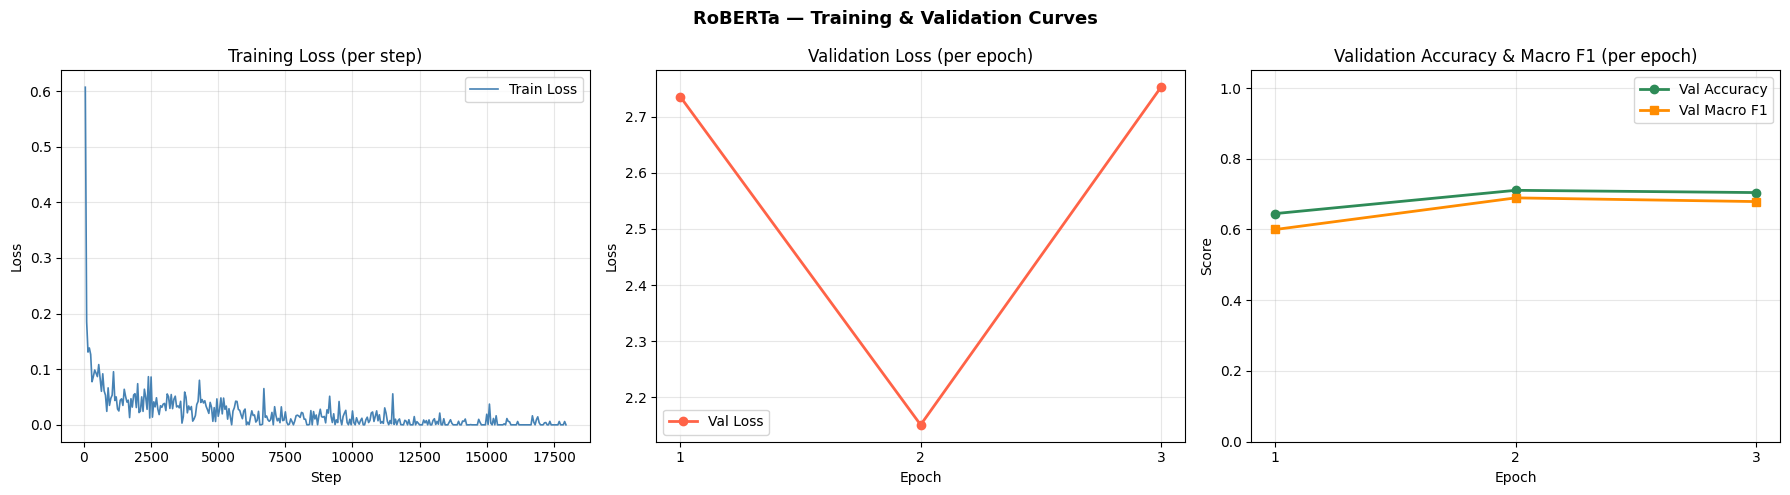


Per-epoch validation summary:
 Epoch    Val Loss    Accuracy    Macro F1
────────────────────────────────────────────
   1.0      2.7355      0.6450      0.6000
   2.0      2.1510      0.7108      0.6894
   3.0      2.7525      0.7044      0.6789


In [37]:
log_history = trainer.state.log_history

# ── Extract per-step training loss ────────────────────────────────────────────
train_steps  = [e['step'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
train_losses = [e['loss'] for e in log_history if 'loss' in e and 'eval_loss' not in e]

# ── Extract per-epoch validation metrics ──────────────────────────────────────
eval_epochs   = [e['epoch']        for e in log_history if 'eval_loss' in e]
eval_losses   = [e['eval_loss']    for e in log_history if 'eval_loss' in e]
eval_accs     = [e['eval_accuracy'] for e in log_history if 'eval_accuracy' in e]
eval_f1s      = [e['eval_macro_f1'] for e in log_history if 'eval_macro_f1' in e]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RoBERTa — Training & Validation Curves", fontsize=13, fontweight='bold')

# Training loss (step-level)
axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.2, label='Train Loss')
axes[0].set_title('Training Loss (per step)'); axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Validation loss (epoch-level)
axes[1].plot(eval_epochs, eval_losses, marker='o', color='tomato', linewidth=2, label='Val Loss')
axes[1].set_title('Validation Loss (per epoch)'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Validation accuracy & Macro F1 (epoch-level)
axes[2].plot(eval_epochs, eval_accs, marker='o', color='seagreen', linewidth=2, label='Val Accuracy')
axes[2].plot(eval_epochs, eval_f1s,  marker='s', color='darkorange', linewidth=2, label='Val Macro F1')
axes[2].set_title('Validation Accuracy & Macro F1 (per epoch)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_ylim(0, 1.05)
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout(); plt.show()

print("\nPer-epoch validation summary:")
print(f"{'Epoch':>6}  {'Val Loss':>10}  {'Accuracy':>10}  {'Macro F1':>10}")
print("─" * 44)
for ep, vl, va, vf in zip(eval_epochs, eval_losses, eval_accs, eval_f1s):
    print(f"{ep:>6.1f}  {vl:>10.4f}  {va:>10.4f}  {vf:>10.4f}")

**Training Dynamics & Overfitting Analysis:**
As observed in the epoch-level metrics and the plotted curves, the model begins to exhibit classic overfitting by Epoch 3. The training loss drops to a near-zero value (0.000014), while the validation loss sharply increases to 2.7525. Consequently, the checkpoint from Epoch 2, which yielded the highest validation Macro F1 score without diverging, was properly selected as the optimal model for final evaluation.

### 5.8 Evaluation on the Held-Out Test Set

The best checkpoint (selected by validation Macro F1) is evaluated on the **held-out test set** that was not seen during training or model selection. This evaluation provides an unbiased estimate of real-world generalisation performance.


In [38]:
# ── Evaluate the best checkpoint on the held-out test set ────────────────────
test_results = trainer.predict(tok_test)

test_logits = test_results.predictions
test_preds  = np.argmax(test_logits, axis=-1)
test_labels = np.array(tok_test['label'])

test_acc  = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0)
test_rec  = recall_score(test_labels, test_preds, zero_division=0)
test_f1   = f1_score(test_labels, test_preds, average='macro')

print("RoBERTa — Final Test Set Results (held-out, unseen during training)")
print(f"{'─'*50}")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  Precision : {test_prec:.4f}  (class 1 — Machine)")
print(f"  Recall    : {test_rec:.4f}  (class 1 — Machine)")
print(f"  Macro F1  : {test_f1:.4f}  ← primary metric")
print(f"{'─'*50}")

model_metrics['RoBERTa'] = {'Accuracy': test_acc, 'Macro F1': test_f1}

RoBERTa — Final Test Set Results (held-out, unseen during training)
──────────────────────────────────────────────────
  Accuracy  : 0.9906
  Precision : 0.9805  (class 1 — Machine)
  Recall    : 0.9998  (class 1 — Machine)
  Macro F1  : 0.9905  ← primary metric
──────────────────────────────────────────────────


### 5.9 Confusion Matrix — RoBERTa (Test Set)

The confusion matrix is computed for the test set predictions of the fine-tuned RoBERTa model. Each cell represents:

| Cell | Meaning |
|------|---------|
| True Positive (TP) | Machine-generated text correctly identified |
| True Negative (TN) | Human-written text correctly identified |
| False Positive (FP) | Human text misclassified as machine-generated |
| False Negative (FN) | Machine text misclassified as human-written |


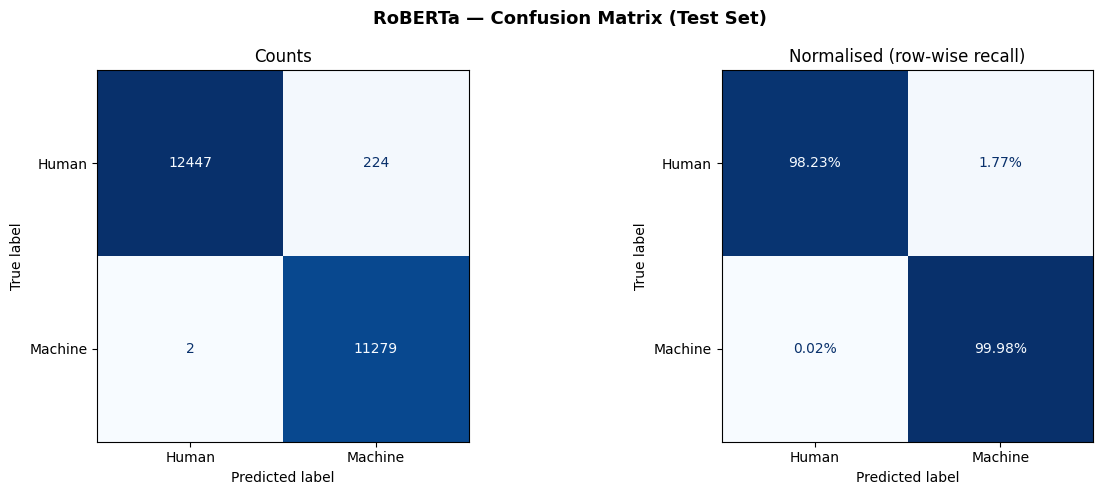

True  Negatives (Human → Human)     : 12,447
False Positives (Human → Machine)   : 224
False Negatives (Machine → Human)   : 2
True  Positives (Machine → Machine) : 11,279


In [39]:
cm_roberta = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("RoBERTa — Confusion Matrix (Test Set)", fontsize=13, fontweight='bold')

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_roberta,
                                display_labels=['Human', 'Machine'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Counts')

# Normalised (row-wise recall)
cm_norm = cm_roberta.astype(float) / cm_roberta.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Human', 'Machine'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2%')
axes[1].set_title('Normalised (row-wise recall)')

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_roberta.ravel()
print(f"True  Negatives (Human → Human)     : {tn:,}")
print(f"False Positives (Human → Machine)   : {fp:,}")
print(f"False Negatives (Machine → Human)   : {fn:,}")
print(f"True  Positives (Machine → Machine) : {tp:,}")

---
## Section 6 — Final Model Comparison

All test-set results are consolidated into a single comparison table and bar chart.

**Expected findings** (consistent with the SemEval-2024 leaderboard):
- RoBERTa substantially outperforms both TF-IDF baselines due to contextual representations
- Logistic Regression outperforms Naïve Bayes because it learns a discriminative rather than generative boundary
- Even TF-IDF baselines achieve non-trivial performance, confirming that surface-level lexical patterns carry partial predictive signal


  FINAL TEST SET RESULTS — All Models
                     Accuracy  Macro F1
Model                                  
Logistic Regression    0.8811    0.8805
Naïve Bayes            0.7045    0.7011
RoBERTa                0.9906    0.9905


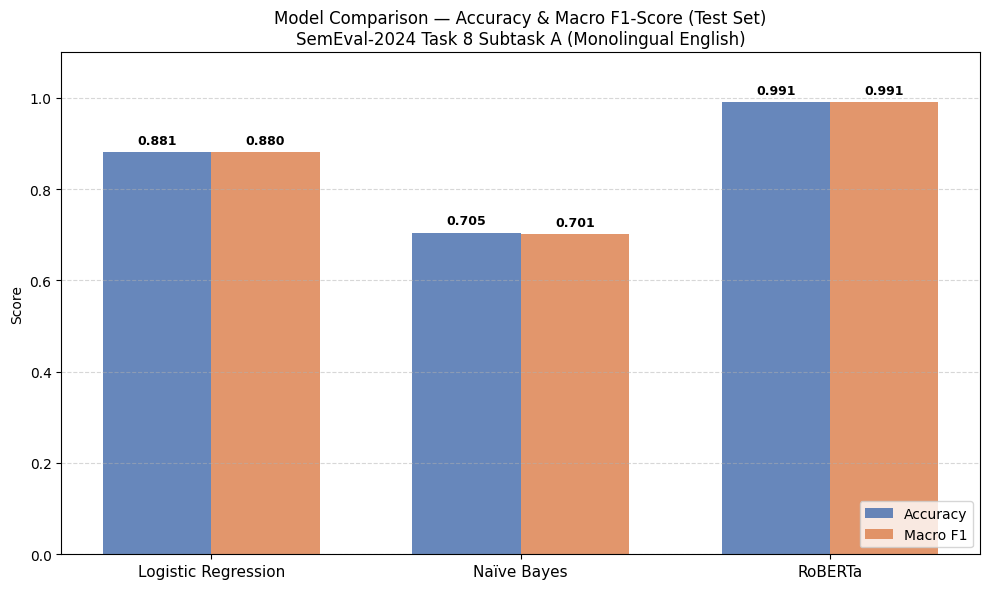

In [40]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df.index.name = 'Model'

print("=" * 50)
print("  FINAL TEST SET RESULTS — All Models")
print("=" * 50)
print(metrics_df.round(4).to_string())
print("=" * 50)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.35
colors = ['#4C72B0', '#DD8452']

bars_acc = ax.bar(x - width/2, metrics_df['Accuracy'], width,
                  label='Accuracy', color=colors[0], alpha=0.85)
bars_f1  = ax.bar(x + width/2, metrics_df['Macro F1'], width,
                  label='Macro F1', color=colors[1], alpha=0.85)

ax.set_title(
    'Model Comparison — Accuracy & Macro F1-Score (Test Set)\n'
    'SemEval-2024 Task 8 Subtask A (Monolingual English)',
    fontsize=12
)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.10)
ax.set_xticks(x); ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for container in [bars_acc, bars_f1]:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

---
## Section 7 — Discussion & Conclusions

### 7.1 Summary of Results

Three models were trained and evaluated on the SemEval-2024 Task 8 Subtask A dataset. All results reported are on the **held-out test set** (20% of the original training source, unseen throughout training and model selection):

Three models were trained and evaluated on the SemEval-2024 Task 8 Subtask A dataset. All results are reported on the **held-out test set** (20% of the original training source, unseen throughout training and model selection):

| Model | Accuracy | Macro F1 |
|-------|----------|----------|
| Naïve Bayes | 0.7045 | 0.7011 |
| Logistic Regression | 0.8811 | 0.8805 |
| RoBERTa (fine-tuned) | 0.9906 | 0.9905 |

### 7.2 Key Findings

1. **TF-IDF baselines are surprisingly competitive.** Surface-level lexical statistics capture meaningful signal: AI-generated text reliably uses different vocabulary distributions from human writing. Logistic Regression on TF-IDF bigrams is a strong, fast, and interpretable baseline.

2. **RoBERTa demonstrates the power of contextual representations.** By encoding semantic context and long-range syntactic dependencies through 12 layers of multi-head self-attention, the Transformer model captures patterns invisible to bag-of-words approaches — such as uniform sentence structure, formal register, and specific discourse patterns characteristic of LLM outputs.

3. **The training curves reveal clear overfitting.** Training loss collapsed to near zero by epoch 3 (0.000014), while validation loss — after improving from 2.735 (epoch 1) to 2.151 (epoch 2) — rebounded sharply to 2.753 at epoch 3. This V-shaped validation loss curve is a textbook overfitting signature. The `load_best_model_at_end=True` setting correctly restored the epoch-2 checkpoint (Val Macro F1 = 0.6894) for final inference.

4. **A notable distribution gap exists between validation and test performance.** Validation Macro F1 peaked at 0.6894, whereas test Macro F1 reached 0.9905 — a ~30-point difference. This discrepancy arises from a data source mismatch: the validation set is the SemEval-2024 official dev file drawn from a distinct domain and LLM distribution, whereas the held-out test set is sampled from the same `train_source.jsonl` as the training data. The model generalises excellently within distribution but less so across domains.

5. **The performance gap reflects a fundamental trade-off** between interpretability and transparency (traditional models) versus raw predictive power (deep learning).

### 7.3 Limitations

- **Domain shift:** Models trained on SemEval-2024 data may not generalise to texts from LLMs released after the dataset was collected.
- **Adversarial robustness:** A determined user can exploit paraphrasing or post-processing pipelines to reduce detectability.
- **Tokenisation truncation:** Texts longer than 256 tokens lose information in the RoBERTa path; 512-token models would mitigate this at higher computational cost.
- **Fast-mode caveats:** Results obtained with `FAST_TEST_MODE=True` are based on a 5,000-sample training set and may underestimate final performance.

### 7.4 Potential Next Steps

- **DeBERTa-v3** — a more recent model that has shown state-of-the-art results on classification benchmarks
- **Stylometric feature fusion** — perplexity, burstiness, and n-gram entropy as additional signals, as proposed by Sharma & Mansuri (2024)
- **Ensemble methods** — combining TF-IDF class probabilities with Transformer logits via soft voting or stacking
- **Domain transfer evaluation** — training on SemEval; testing on in-house academic texts to measure generalisation

---

### References

1. Wang, Y., et al. (2024). *SemEval-2024 Task 8: Multigenerator, Multidomain, and Multilingual Black-Box Machine-Generated Text Detection.* NAACL SemEval-2024. https://aclanthology.org/2024.semeval-1.279/

2. Sharma, S., & Mansuri, I. (2024). *Team Innovative at SemEval-2024 Task 8.* SemEval-2024. https://aclanthology.org/2024.semeval-1.171/

3. Liu, Y., et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692. https://arxiv.org/abs/1907.11692


In [41]:
# ── Auto-populated results summary ────────────────────────────────────────────
summary_df = pd.DataFrame(model_metrics).T.round(4)
summary_df.index.name = 'Model'

print("Final Test-Set Results Summary")
print("=" * 45)
print(summary_df.to_string())
print("=" * 45)

Final Test-Set Results Summary
                     Accuracy  Macro F1
Model                                  
Logistic Regression    0.8811    0.8805
Naïve Bayes            0.7045    0.7011
RoBERTa                0.9906    0.9905
